In [1]:
from calculations.Composition.Composition import Composition
from calculations.Utils.Conditions import Conditions
from calculations.CompositionalModel.CompositionalModel import CompositionalModel
from calculations.EOS.PenelouxVolumeCorrection import PenelouxVolumeCorrection
from calculations.Utils.ResultsViewer import FlashResultsViewer, DLEResultsViewer, SeparatorTestResultsViewer, StandardSeparationResultsViewer
from calculations.Utils.CompositionLoader import CompositionExcelLoader
from calculations.PhaseDiagram.PhaseDiagram_v4 import PhaseDiagram

# KRSNLN

In [ ]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\krsnln.xlsx')
krsnln_dict = excel_loader.load(header=True, sheet='to_model')

In [ ]:
krsnln_rizari_daubert_composition = Composition(zi = krsnln_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'rizari_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

krsnln_pedersen_composition = Composition(zi = krsnln_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pedersen',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_rizari_daubert = PhaseDiagram(zi = krsnln_rizari_daubert_composition, p_max=30, t_max=660, t_min=0, t_step=10)
phase_env_rizari_daubert.calc_phase_diagram('PREOS')
phase_env_rizari_data = phase_env_rizari_daubert.get_phase_diagram_data()
phase_env_pedersen = PhaseDiagram(zi = krsnln_pedersen_composition, p_max=30, t_max=660, t_min=0, t_step=10)
phase_env_pedersen.calc_phase_diagram('PREOS')
phase_env_pedersen_data = phase_env_pedersen.get_phase_diagram_data()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.lineplot(marker='o',data = phase_env_rizari_data, x= phase_env_rizari_data['Temp'], y= phase_env_rizari_data['Up'], color = 'blue', label = 'Rizari-Daubert')
sns.lineplot(marker='o',data = phase_env_rizari_data, x= phase_env_rizari_data['Temp'], y= phase_env_rizari_data['Low'], color = 'blue')
sns.lineplot(marker='o',data = phase_env_pedersen_data, x= phase_env_pedersen_data['Temp'], y= phase_env_pedersen_data['Up'], color = 'red', label = 'Pedersen')
sns.lineplot(marker='o',data = phase_env_pedersen_data, x= phase_env_pedersen_data['Temp'], y= phase_env_pedersen_data['Low'], color = 'red')

sns.scatterplot(x=[65], y = [13], color = 'green', label = 'Psat_fact')
plt.title('Krasnoleninskoe Phase Envelope')
plt.xlabel('Temperature, C')
plt.ylabel('Pressure, MPa')

# PRRZLM №200839

In [ ]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\prrzlm.xlsx')
przlm_dict = excel_loader.load(header=True, sheet='to_model')

### Фактические данные

In [ ]:
p_sat = 120.47


## Создаем базовую модель и сравниваемся с PVTSIM

In [ ]:
przlm_comp = Composition(przlm_dict)

In [ ]:
przlm_comp.COMPOSITION_PROPERTIES

In [ ]:
przlm_model = CompositionalModel(przlm_comp)

In [ ]:
conds = Conditions(5,50)

In [ ]:
przlm_model.flash(conds)

In [ ]:
przlm_model.saturation_pressure(60)

### Проверяем сепаратор тест

In [ ]:
przlm_model.experiments.SEPARATORTEST.calculate_3stages([0.7, 0.5, 0.1], [20, 20, 20])

## Начинаем играть корреляциями

In [ ]:
prr_base_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'rizari_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})


In [ ]:
prr_pedersen_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pedersen',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

### Какие то расчеты, можно и убрать

In [ ]:
model_base = CompositionalModel(prr_base_comp)
model_kesler = CompositionalModel(prr_pedersen_comp)

In [ ]:
model_kesler.experiments.SEPARATORTEST_MOD.calculate(150, 60, [0.76,0.3,0.101], [55, 58.3, 20])

In [ ]:
model_base.saturation_pressure(58)

In [ ]:
dleresview = DLEResultsViewer()
dleresview.view(model_kesler.experiments.SEPARATORTEST_MOD.result)

### Расчет фазовой по корреляции Ризари-Дауберта

In [ ]:
phase_env_prr_rizari_daubert = PhaseDiagram(prr_base_comp, p_max=35, t_max= 550, t_min=0, t_step=10)

In [ ]:
phase_env_prr_rizari_daubert.calc_phase_diagram('PREOS')

In [ ]:
phase_env_data_1 = phase_env_prr_rizari_daubert.get_phase_diagram_data()

### Расчет фазовой по корреляции Pedersen

In [ ]:
phase_env_prr_pedersen = PhaseDiagram(prr_pedersen_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_pedersen.calc_phase_diagram('PREOS')

In [ ]:
phase_env_data_2 = phase_env_prr_pedersen.get_phase_diagram_data()

### Расчет по корреляции Kesler-Lee

In [ ]:
prr_kesler_lee_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'kesler_lee',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_prr_kesler_lee = PhaseDiagram(prr_kesler_lee_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_kesler_lee.calc_phase_diagram('PREOS')

In [ ]:
phase_env_data_3 = phase_env_prr_kesler_lee.get_phase_diagram_data()

###  Расчет по корреляции Sim-Daubert

In [ ]:
prr_sim_daubert_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'sim_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_prr_sim_daubert = PhaseDiagram(prr_sim_daubert_comp, p_max=35, t_max= 550, t_min=0, t_step=10)
phase_env_prr_sim_daubert.calc_phase_diagram('PREOS')

In [ ]:
phase_env_data_4 = phase_env_prr_sim_daubert.get_phase_diagram_data()

### Pc Br **не работает!**

In [ ]:
prr_pc_eos_comp = Composition(przlm_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pc_from_eos',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

## Построение общей фазовой и сравнение результатов

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.lineplot(marker='o',data = phase_env_data_1, x= phase_env_data_1['Temp'], y= phase_env_data_1['Up'], color = 'blue', label = 'Rizari-Daubert')
sns.lineplot(marker='o',data = phase_env_data_1, x= phase_env_data_1['Temp'], y= phase_env_data_1['Low'], color = 'blue')
sns.lineplot(marker='o',data = phase_env_data_2, x= phase_env_data_2['Temp'], y= phase_env_data_2['Up'], color = 'red', label = 'Pedersen')
sns.lineplot(marker='o',data = phase_env_data_2, x= phase_env_data_2['Temp'], y= phase_env_data_2['Low'], color = 'red')
sns.lineplot(marker='o',data = phase_env_data_3, x= phase_env_data_3['Temp'], y= phase_env_data_3['Up'], color = 'gray', label = 'Kesler-Lee')
sns.lineplot(marker='o',data = phase_env_data_3, x= phase_env_data_3['Temp'], y= phase_env_data_3['Low'], color = 'gray')
sns.lineplot(marker='o',data = phase_env_data_4, x= phase_env_data_4['Temp'], y= phase_env_data_4['Up'], color = 'black', label = 'Sim-Daubert')
sns.lineplot(marker='o',data = phase_env_data_4, x= phase_env_data_4['Temp'], y= phase_env_data_4['Low'], color = 'black')
sns.scatterplot(x=[65], y = [13], color = 'green', label = 'Psat_fact')
plt.title('Prirazlomnoe Phase Envelope')
plt.xlabel('Temperature, C')
plt.ylabel('Pressure, MPa')


# ZAP_MES

In [2]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\zap_mes.xlsx')
zap_mes_dict = excel_loader.load(header=True, sheet='to_model')

In [3]:
zap_mes_comp = Composition(zap_mes_dict)

In [4]:
phase_env_zap_mes = PhaseDiagram(zi = zap_mes_comp, p_max=14, t_min=0, t_max=750, t_step= 10)

In [5]:
phase_env_zap_mes.calc_phase_diagram('PREOS')

Pb найдено: 0.2672725677490234
Pb найдено: 0.2926200866699219
Pb найдено: 0.3175464630126953
Pb найдено: 0.34184112548828116
Pb найдено: 0.3653724670410156
Pb найдено: 0.3879825592041015
Pb найдено: 0.4095924377441406
Pb найдено: 0.43007049560546873
Pb найдено: 0.44933776855468754
Pb найдено: 0.4674205780029297
Pb найдено: 0.4842399597167969
Pb найдено: 0.49976959228515627
Pb найдено: 0.5140357971191407
Pb найдено: 0.52703857421875
Pb найдено: 0.53883056640625
Pb найдено: 0.5494117736816406
Pb найдено: 0.5588874816894531
Pb найдено: 0.5673103332519531
Pb найдено: 0.5746803283691408
Pb найдено: 0.5812080383300782
Pb найдено: 0.5869461059570313
Pb найдено: 0.5919998168945313
Pb найдено: 0.5964744567871094
Pb найдено: 0.6004753112792969
Pb найдено: 0.6042129516601562
Pb найдено: 0.6077926635742187
Pb найдено: 0.6113723754882813
Pb найдено: 0.6151100158691407
Pb найдено: 0.6191635131835936
Pb найдено: 0.6236907958984375
Pb найдено: 0.628955078125
Pb найдено: 0.6350616455078126
Pb найдено: 

In [6]:
zap_mes_phase_data = phase_env_zap_mes.get_phase_diagram_data()

In [7]:
import seaborn as sns

<Axes: xlabel='Temp', ylabel='Up'>

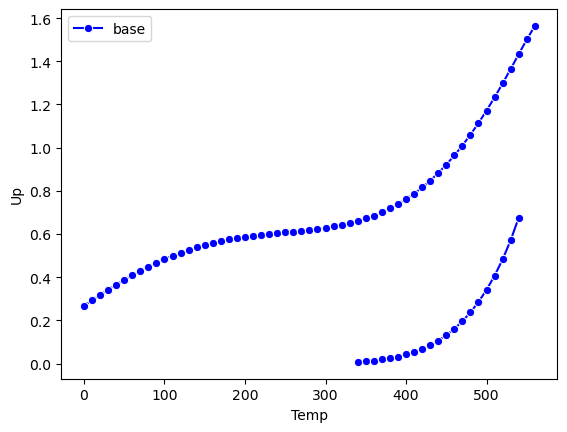

In [8]:
sns.lineplot(marker='o',data = zap_mes_phase_data, x= zap_mes_phase_data['Temp'], y= zap_mes_phase_data['Up'], color = 'blue', label = 'base')
sns.lineplot(marker='o',data = zap_mes_phase_data, x= zap_mes_phase_data['Temp'], y= zap_mes_phase_data['Low'], color = 'blue')

# NP

In [10]:
excel_loader = CompositionExcelLoader(r'C:\Users\user\Desktop\PVT_TSU\diss\np.xlsx')
np_dict = excel_loader.load(header=True, sheet='to_model')

### Расчет УРС АИ

In [12]:
base_comp = Composition(np_dict)
model_ai = CompositionalModel(base_comp, eos = 'BRSEOS')

In [ ]:
conds = Conditions(5,50)
model_ai.flash(conds)

#### Расчет фазовой для уравнения АИ

In [14]:
phase_env_ai = PhaseDiagram(base_comp, p_max=20, t_min=0, t_max=550, t_step=10)
phase_env_ai.calc_phase_diagram('BRSEOS')

Pb найдено: 8.171545410156252
Pb найдено: 8.734704589843748
Pb найдено: 9.25677490234375
Pb найдено: 9.737756347656251
Pb найдено: 10.17822265625
Pb найдено: 10.576171875
Pb найдено: 10.936279296875
Pb найдено: 11.25732421875
Pb найдено: 11.54052734375
Pb найдено: 11.787109375
Pb найдено: 11.99951171875
Pb найдено: 12.177734375
Pdew найдено: 0.0038208719342947006
Pb найдено: 12.32177734375
Pdew найдено: 0.006051745731383562
Pb найдено: 12.4365234375
Pdew найдено: 0.009316338691860437
Pb найдено: 12.520751953125
Pdew найдено: 0.013970641884952784
Pb найдено: 12.57568359375
Pdew найдено: 0.02048422582447529
Pb найдено: 12.603759765625
Pdew найдено: 0.02935255179181695
Pb найдено: 12.60498046875
Pdew найдено: 0.04125623032450676
Pb найдено: 12.579345703125
Pdew найдено: 0.05691186524927616
Pb найдено: 12.529296875
Pdew найдено: 0.0771418958902359
Pb найдено: 12.4560546875
Pdew найдено: 0.10310988873243332
Pb найдено: 12.3583984375
Pdew найдено: 0.1357734203338623
Pb найдено: 12.2387695312

In [16]:
phase_env_ai_data = phase_env_ai.get_phase_diagram_data()

#### Расчет фазовой для PR

In [17]:
phase_env_pr = PhaseDiagram(base_comp, p_max=20, t_min=0, t_max=550, t_step=10)
phase_env_pr.calc_phase_diagram('PREOS')

Pb найдено: 6.714703369140626
Pb найдено: 7.372729492187501
Pb найдено: 8.007189941406253
Pb найдено: 8.612646484374999
Pb найдено: 9.1854736328125
Pb найдено: 9.722045898437502
Pb найдено: 10.2197265625
Pb найдено: 10.6787109375
Pb найдено: 11.09619140625
Pdew найдено: 0.0013598066288977861
Pb найдено: 11.474609375
Pdew найдено: 0.0022706808522343636
Pb найдено: 11.8115234375
Pb найдено: 12.109375
Pdew найдено: 0.005756877362728119
Pb найдено: 12.3681640625
Pdew найдено: 0.008775629103183746
Pb найдено: 12.587890625
Pdew найдено: 0.013061165809631348
Pb найдено: 12.769775390625
Pdew найдено: 0.018973646219819784
Pb найдено: 12.9150390625
Pdew найдено: 0.02699829638004303
Pb найдено: 13.02490234375
Pdew найдено: 0.037711719051003456
Pb найдено: 13.09814453125
Pdew найдено: 0.05166428163647652
Pb найдено: 13.1396484375
Pdew найдено: 0.06972217932343483
Pb найдено: 13.14697265625
Pdew найдено: 0.09268037974834442
Pb найдено: 13.1201171875
Pdew найдено: 0.12151964008808136
Pb найдено: 13.

In [18]:
phase_env_pr_data = phase_env_pr.get_phase_diagram_data()

#### Расчет фазовой для SRK

In [21]:
phase_env_srk = PhaseDiagram(base_comp, p_max=20, t_min=0, t_max=550, t_step=10)
phase_env_srk.calc_phase_diagram('SRKEOS')

Pb найдено: 6.94854736328125
Pb найдено: 7.604156494140625
Pb найдено: 8.231970214843752
Pb найдено: 8.82896728515625
Pb найдено: 9.388500976562499
Pb найдено: 9.911779785156249
Pb найдено: 10.394287109375
Pb найдено: 10.836181640625
Pb найдено: 11.23779296875
Pb найдено: 11.59912109375
Pb найдено: 11.9189453125
Pdew найдено: 0.0034214043989777565
Pb найдено: 12.19970703125
Pdew найдено: 0.005421699024736881
Pb найдено: 12.442626953125
Pdew найдено: 0.008353814482688904
Pb найдено: 12.646484375
Pdew найдено: 0.012530991807579994
Pb найдено: 12.81494140625
Pdew найдено: 0.018344142008572817
Pb найдено: 12.94677734375
Pdew найдено: 0.026274435222148895
Pb найдено: 13.04443359375
Pdew найдено: 0.03692233934998512
Pb найдено: 13.10791015625
Pdew найдено: 0.05090275779366493
Pb найдено: 13.1396484375
Pdew найдено: 0.06897032260894775
Pb найдено: 13.1396484375
Pdew найдено: 0.09202726185321808
Pb найдено: 13.10791015625
Pdew найдено: 0.12120656669139862
Pb найдено: 13.046875
Pdew найдено: 0.

In [22]:
phase_env_srk_data = phase_env_srk.get_phase_diagram_data()

#### Сравнение фазовых AI, SRK и PR

In [19]:
import seaborn as sns

<Axes: xlabel='Temp', ylabel='Up'>

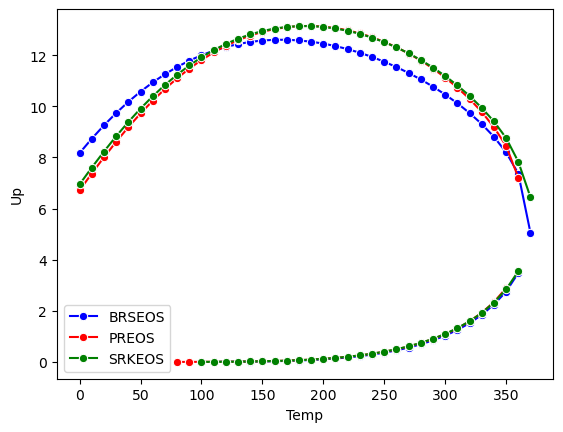

In [25]:
sns.lineplot(marker='o',data = phase_env_ai_data, x= phase_env_ai_data['Temp'], y= phase_env_ai_data['Up'], color = 'blue', label = 'BRSEOS')
sns.lineplot(marker='o',data = phase_env_ai_data, x= phase_env_ai_data['Temp'], y= phase_env_ai_data['Low'], color = 'blue')
sns.lineplot(marker='o',data = phase_env_pr_data, x= phase_env_pr_data['Temp'], y= phase_env_pr_data['Up'], color = 'red', label = 'PREOS')
sns.lineplot(marker='o',data = phase_env_pr_data, x= phase_env_pr_data['Temp'], y= phase_env_pr_data['Low'], color = 'red')
sns.lineplot(marker='o',data = phase_env_srk_data, x= phase_env_srk_data['Temp'], y= phase_env_srk_data['Up'], color = 'green', label = 'SRKEOS')
sns.lineplot(marker='o',data = phase_env_srk_data, x= phase_env_srk_data['Temp'], y= phase_env_srk_data['Low'], color = 'green')

### Rizari_daubert

In [ ]:
np_comp_rizari_daubert = Composition(np_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'rizari_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_rd = PhaseDiagram(np_comp_rizari_daubert, p_max=25, t_min=0, t_max=550, t_step=10)
phase_env_rd.calc_phase_diagram('PREOS')

In [ ]:
np_data_rizari_daubert = phase_env_rd.get_phase_diagram_data()

### pedersen

In [ ]:
np_comp_pedersen = Composition(np_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'pedersen',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_pd = PhaseDiagram(np_comp_pedersen, p_max=25, t_min=0, t_max=550, t_step=10)
phase_env_pd.calc_phase_diagram('PREOS')
np_data_pedersen = phase_env_pd.get_phase_diagram_data()

### Kesler-Lee

In [ ]:
np_comp_kesler_lee = Composition(np_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'kesler_lee',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_kl = PhaseDiagram(np_comp_kesler_lee, p_max=25, t_min=0, t_max=550, t_step=10)
phase_env_kl.calc_phase_diagram('PREOS')
np_data_kesler_lee = phase_env_kl.get_phase_diagram_data()

### Sim_Daubert

In [ ]:
np_comp_sim_daubert = Composition(np_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'sim_daubert',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_sd = PhaseDiagram(np_comp_sim_daubert, p_max=25, t_min=0, t_max=550, t_step=10)
phase_env_sd.calc_phase_diagram('PREOS')
np_data_sim_d = phase_env_sd.get_phase_diagram_data()

### Standing

In [ ]:
np_comp_standing = Composition(np_dict, c6_plus_correlations= {'critical_temperature': 'pedersen',
                                                    'critical_pressure': 'standing',
                                                    'acentric_factor': 'rizari_al_sahhaf',
                                                    'critical_volume': 'hall_yarborough',
                                                    'k_watson': 'k_watson',
                                                    'shift_parameter': 'jhaveri_youngren'})

In [ ]:
phase_env_std = PhaseDiagram(np_comp_standing, p_max=25, t_min=0, t_max=550, t_step=10)
phase_env_std.calc_phase_diagram('PREOS')
np_data_std = phase_env_std.get_phase_diagram_data()

## Свод график

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
sns.lineplot(marker='o',data = np_data_rizari_daubert, x= np_data_rizari_daubert['Temp'], y= np_data_rizari_daubert['Up'], color = 'blue', label = 'Rizari-Daubert')
sns.lineplot(marker='o',data = np_data_rizari_daubert, x= np_data_rizari_daubert['Temp'], y= np_data_rizari_daubert['Low'], color = 'blue')
sns.lineplot(marker='o',data = np_data_pedersen, x= np_data_pedersen['Temp'], y= np_data_pedersen['Up'], color = 'red', label = 'Pedersen')
sns.lineplot(marker='o',data = np_data_pedersen, x= np_data_pedersen['Temp'], y= np_data_pedersen['Low'], color = 'red')
sns.lineplot(marker='o',data = np_data_kesler_lee, x= np_data_kesler_lee['Temp'], y= np_data_kesler_lee['Up'], color = 'green', label = 'Kesler-Lee')
sns.lineplot(marker='o',data = np_data_kesler_lee, x= np_data_kesler_lee['Temp'], y= np_data_kesler_lee['Low'], color = 'green')
sns.lineplot(marker='o',data = np_data_sim_d, x= np_data_sim_d['Temp'], y= np_data_sim_d['Up'], color = 'gray', label = 'Sim-Daubert')
sns.lineplot(marker='o',data = np_data_sim_d, x= np_data_sim_d['Temp'], y= np_data_sim_d['Low'], color = 'gray')
# sns.lineplot(marker='o',data = np_data_std, x= np_data_std['Temp'], y= np_data_std['Up'], color = 'gray', label = 'Standing')
# sns.lineplot(marker='o',data = np_data_std, x= np_data_std['Temp'], y= np_data_std['Low'], color = 'gray')
sns.scatterplot(x=[57.7], y = [11.7], label = 'Psat_fact', marker = 'x')
plt.title('Novoport phase envelope')
plt.ylabel('Pressure, MPa')
plt.xlabel('Temp, C')